<a href="https://colab.research.google.com/github/DHRUVCHARNE/AI-Learn-Notebooks/blob/main/micrograd_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [773]:
import math
import numpy as np
import matplotlib.pyplot as plt
# Tells notebook to render plots directly in the output cell
# instead of separate interactive window
%matplotlib inline

In [774]:
def f(x):
  return 3*x**2 - 6*x + 5

In [775]:
f(4)

29

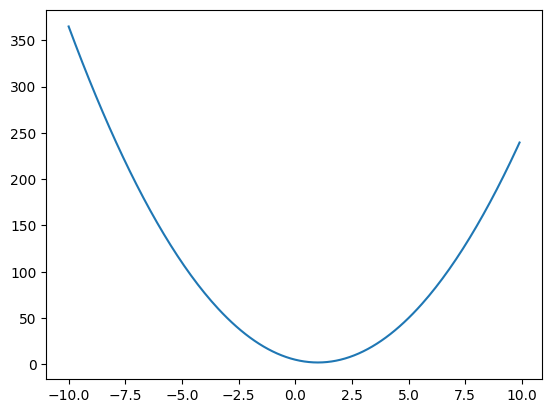

In [776]:
xs=np.arange(-10,10,0.1)
ys = f(xs)
plt.plot(xs,ys)

In [777]:
h=0.0000000001
x=1.0 #slope zero
(f(x+h)-f(x))/h

0.0

In [778]:
def g(a,b,c):
  return a*b + c


In [779]:
a = 1.0
b=2.0
c=3.0
print(g(a,b,c))

5.0


In [780]:
# slope wrt a
h=0.0001
d_a=(g(a+h,b,c)-g(a,b,c))/h
print(d_a)

1.9999999999953388


In [781]:
#slope wrt b
d_b=(g(a,b+h,c)-g(a,b,c))/h
print(d_b)

0.9999999999976694


In [782]:
#slope wrt c
d_c=(g(a,b,c+h)-g(a,b,c))/h
print(d_c)

0.9999999999976694


In [783]:
# Value Class
class Value:
  def __init__(self,data,_children=(),_op='',label=''):
    self.data=data
    self._prev=set(_children)
    self._op=_op
    self.label=label
    self.grad=0
    self._backward=lambda:None
  def __repr__(self): #Display Implementation in python
    return f"Value(data={self.data})"
  def __add__(self,other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data + other.data,(self,other),'+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward=_backward
    return out

  def __mul__(self,other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data * other.data,(self,other),'*')
    def _backward():
      self.grad+=other.data * out.grad
      other.grad+=self.data * out.grad
    out._backward = _backward
    return out
  def __pow__(self,other):
    assert isinstance(other,(int,float)), "only support int/float powers for now"
    out = Value(self.data**other,(self,),f'**{other}')
    def _backward():
      self.grad += (other * self.data**(other-1)) * out.grad
    out._backward=_backward
    return out
  def __neg__(self):
    return self * -1
  def __sub__(self,other):
    return self + (-other)
  def __rmul__(self,other):
    return self * other
  def __radd__(self,other):
    return self + other
  def __truediv__(self,other):
    return self * other**-1
  def tanh(self):
    n=self.data
    t=(math.exp(2*n)-1)/(math.exp(2*n)+1)
    out = Value(t,(self,),'tanh')
    def _backward():
      self.grad+=(1-t**2) * out.grad
    out._backward=_backward
    return out
  def exp(self):
    x=self.data
    out = Value(math.exp(x),(self,),'exp')
    def _backward():
      self.grad+=out.data * out.grad
    out._backward=_backward
    return out
  def backward(self):
    topo=[]
    visited=set()
    def build_topo(v):
        if v not in visited:
           visited.add(v)
           for child in v._prev:
               build_topo(child)
           topo.append(v)
    build_topo(self)
    self.grad=1
    for node in reversed(topo):
      node._backward()



In [784]:
a=Value(2.3,label='a')
a

Value(data=2.3)

In [785]:
b=Value(-2.0,label='b')
a+b

Value(data=0.2999999999999998)

In [786]:
a*b

Value(data=-4.6)

In [787]:
c=Value(8.5,label='c')
e=Value(3,label='e')
d=a*b+c*e;d.label='d'
# d._prev
d._op
L=d + Value(3.5,label='f');L.label='L'

In [788]:
# Visualization of the expression
from graphviz import Digraph
def trace(root):
  # Builds a set of all nodes and edges in a graph
  nodes,edges = set(),set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child,v))
        build(child)
  build(root)
  return nodes,edges

def draw_dot(root):
  dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) # LR = Left to Right
  nodes,edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # For any node in the value graph, create a rectangular 'record' node for it
    dot.node(name=uid,label="{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape="record")
    if n._op:
      # If this value is an outcome of some operation then create an op node for it
      dot.node(name=uid+n._op,label=n._op)
      # Connect the op node to it
      dot.edge(uid+n._op,uid)
  for n1,n2 in edges:
      # Connect n1 to the op node of n2
      dot.edge(str(id(n1)),str(id(n2))+n2._op)
  return dot


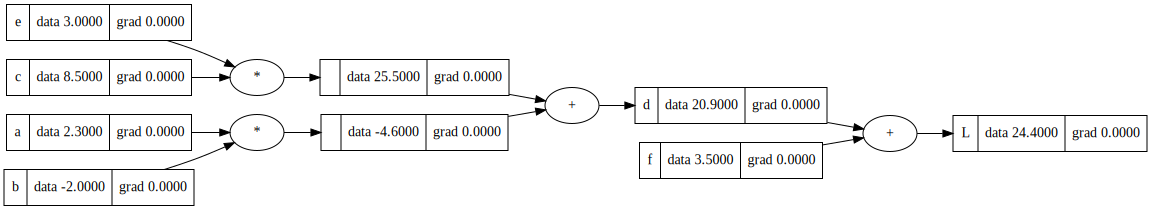

In [789]:
draw_dot(L)

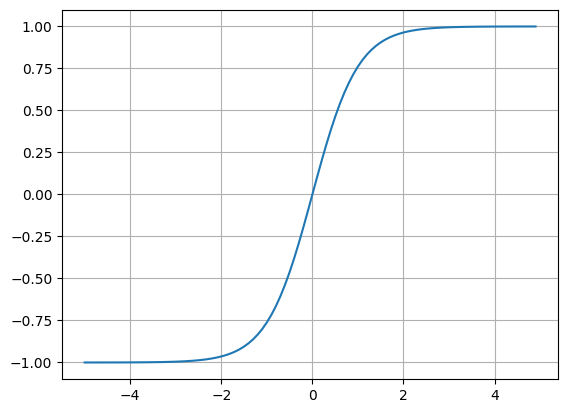

In [790]:
plt.plot(np.arange(-5,5,0.1),np.tanh(np.arange(-5,5,0.1)));
plt.grid()

In [791]:
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.88137,label='b')
x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1w1x2w2'
n=x1w1x2w2+b;n.label='n'
o=n.tanh();o.label='o'


In [792]:
o.backward()

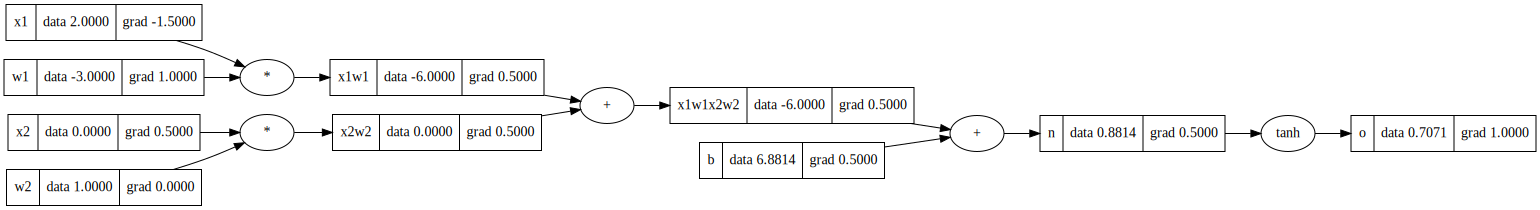

In [793]:
draw_dot(o)

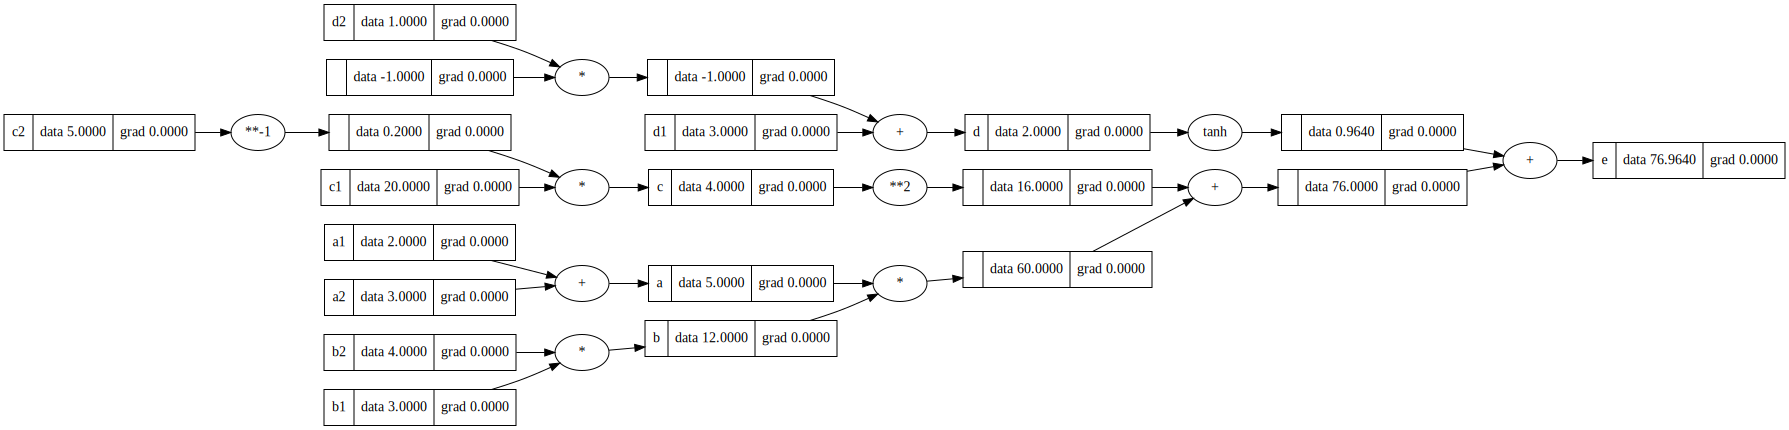

In [794]:
a=Value(2.0,label='a1')+Value(3.0,label='a2');a.label='a'
b=Value(3.0,label='b1')*Value(4,label='b2');b.label='b'
c=Value(20.0,label='c1')/Value(5.0,label='c2');c.label='c'
d=Value(3.0,label='d1')-Value(1.0,label='d2');d.label='d'
e=(a*b)+(c**2)+ d.tanh();e.label='e'
draw_dot(e)

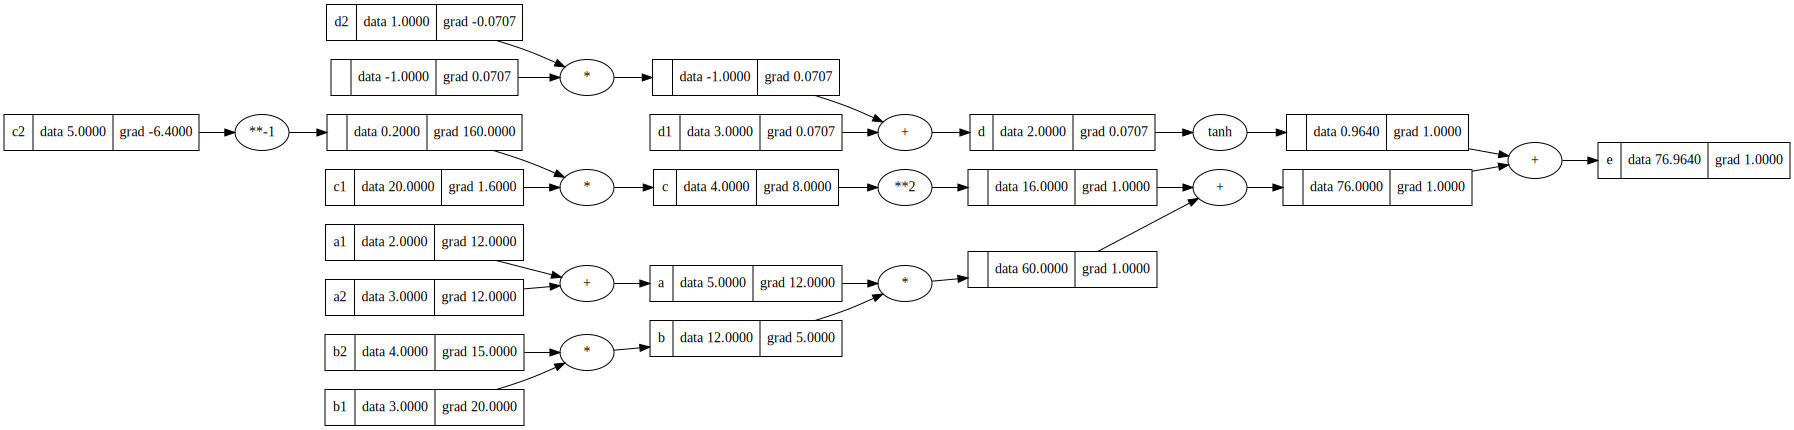

In [795]:
e.backward()
draw_dot(e)

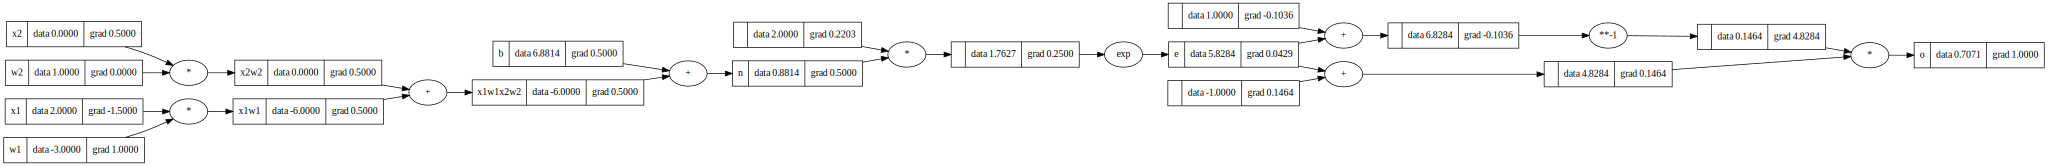

In [796]:
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.88137,label='b')
x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1w1x2w2'
n=x1w1x2w2+b;n.label='n'
e=(2*n).exp();e.label='e'
o=(e-1)/(e+1)
o.label='o'
o.backward()
draw_dot(o)


In [797]:
import torch
import random

In [798]:
x1=torch.Tensor([2.0]).double();x1.requires_grad = True
x2=torch.Tensor([0.0]).double();x2.requires_grad = True
w1=torch.Tensor([-3.0]).double();w1.requires_grad = True
w2=torch.Tensor([1.0]).double();w2.requires_grad = True
b=torch.Tensor([6.88137]).double();b.requires_grad = True
n=x1*w1 + x2*w2 + b
o=torch.tanh(n)
o.backward()
print('-----')
print(x1.grad.item())
print(x2.grad.item())
print(w1.grad.item())
print(w2.grad.item())
print(o.data.item())


-----
-1.500007465833125
0.5000024886110417
1.0000049772220834
0.0
0.7071050214706146


In [799]:
torch.Tensor([[1,2,3],[4,5,6],[7,8,9]]).double().dtype

torch.float64

In [800]:
class Neuron:
  def __init__(self,nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  def __call__(self,x):
    act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
    out=act.tanh()
    return out
  def parameters(self):
    return self.w + [self.b]
class Layer:
  def __init__(self,nin,nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  def __call__(self,x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs)==1 else outs
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:
  def __init__(self,nin,nouts):
    sz=[nin]+nouts
    self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
  def __call__(self,x):
    for layer in self.layers:
      x=layer(x)
    return x
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]





In [801]:
x=[2.0,3.0,-5.0]
n= MLP(3,[4,4,1])
n(x)

Value(data=0.931259952677552)

In [802]:
len(n.parameters())

41

In [803]:
xs=[
    [2.0,3.0,-1.0],
    [2.0,-1.0,1.5],
    [0.5,0.5,1.0],
    [3.0,-2.0,2.7]
]
ys=[1.0,-1.0,-1.0,1.0]
ypred=[n(x) for x in xs]
ypred

[Value(data=0.91374708645274),
 Value(data=0.2020318532119265),
 Value(data=0.23107385754392654),
 Value(data=0.20441782308215778)]

In [804]:
loss = sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))
loss

Value(data=3.6008139841889064)

In [805]:
no_of_steps=10
for k in range(no_of_steps):
  # forward_pass
  ypred=[n(x) for x in xs]
  loss = sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))
  # backward propagation
  for p in n.parameters():
    p.grad=0.0
  loss.backward()
  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad
  print(k,loss.data)

0 3.6008139841889064
1 2.772633426031917
2 2.748706850093537
3 2.7245739952052253
4 2.698113120969862
5 2.6691519355823448
6 2.637452786371717
7 2.602483685021034
8 2.563364147396463
9 2.5188867855662833


In [806]:
ypred

[Value(data=0.895840619414708),
 Value(data=-0.31447204793484884),
 Value(data=-0.3186308587427247),
 Value(data=-0.25452187277944854)]